In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [40]:
import pandas as pd
import zipfile

# Unzip the local file
with zipfile.ZipFile('student.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Load the dataset
data = pd.read_csv('student-mat.csv', sep=';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [41]:
# Create Pass/Fail target variable
data['result'] = data['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Check distribution
data['result'].value_counts()

,count
result,
1,265
0,130


In [42]:
# Convert categorical variables into numerical using one-hot encoding
data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [43]:
# Separate features and target
X = data_encoded.drop(['G1', 'G2', 'G3', 'result'], axis=1)
y = data_encoded['result']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (395, 39)
Target shape: (395,)


In [44]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (316, 39)
Testing set size: (79, 39)


In [45]:
# Logistic Regression Model
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)


Logistic Regression Accuracy: 0.7341772151898734


In [46]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.6455696202531646


In [47]:
# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6582278481012658


In [48]:
# Support Vector Machine Model
svm_model = SVC()

svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6582278481012658


In [49]:
# K-Nearest Neighbors Model
knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.6835443037974683


In [54]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [log_accuracy, dt_accuracy, rf_accuracy, svm_accuracy, knn_accuracy]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,0.734177
4,KNN,0.683544
2,Random Forest,0.658228
3,SVM,0.658228
1,Decision Tree,0.645570


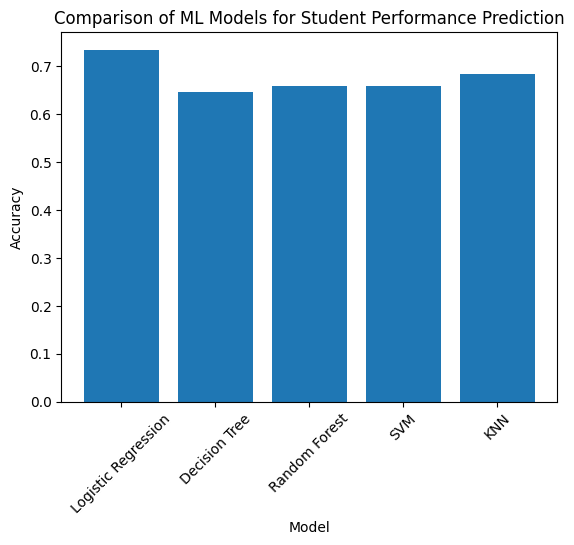

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results['Model'], results['Accuracy'])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models for Student Performance Prediction")
plt.show()

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[12 15]
 [ 6 46]]
